<a href="https://colab.research.google.com/github/salma1924/twitter-sentiment-analysis_Datamining2026/blob/main/miningf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Twitter Sentiment Analysis — Data Mining Final Project

## Phase 1: Business Understanding

**Problem Statement:** Social media platforms generate millions of opinion-rich messages daily.
Brands, researchers, and policymakers need automated tools to monitor public sentiment at scale.

**Objective:** Build a pipeline that classifies tweets as positive or negative using the
Sentiment140 dataset (1.6M tweets), and surface actionable insights via an interactive dashboard.

**Success Criteria:**
- Macro F1-score ≥ 0.75 on the held-out test set
- ROC-AUC ≥ 0.80
- At least 4 mining techniques applied (clustering, classification, text mining, regression)
- Fully functional interactive dashboard

**Domain Context:** This pipeline simulates a real-world social media monitoring tool,
useful for brand reputation management, product feedback analysis, and trend detection.

> ⚠️ **Setup:** Replace `YOUR_KAGGLE_USERNAME` and `YOUR_KAGGLE_KEY` in the next cell
> with your actual Kaggle credentials before running.

In [89]:
import json

token = """
{"username":"YOUR_KAGGLE_USERNAME","key":"YOUR_KAGGLE_KEY"}
"""
with open("kaggle.json", "w") as f:
    f.write(token)


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 166MB/s]



In [5]:
!unzip -o sentiment140.zip

Archive:  sentiment140.zip
  inflating: training.1600000.processed.noemoticon.csv  


## Phase 2: Data Understanding

We load the raw Sentiment140 CSV, rename columns, and remap the target labels from {0, 4}
to binary {0, 1}. We then examine the dataset shape, class balance, missing values,
and duplicate tweets to assess data quality before any processing begins.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("training.1600000.processed.noemoticon.csv",
                 encoding="ISO-8859-1")
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Remap: 4 → 1 so labels are binary 0 (negative) / 1 (positive)
df['target'] = df['target'].map({0: 0, 4: 1})

print(df.shape)
print(df['target'].value_counts())
df.head()

(1599999, 6)
target
1    800000
0    799999
Name: count, dtype: int64


,target,id,date,flag,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [8]:
print("=== Missing values ===")
print(df.isnull().sum())

print("\n=== Duplicate tweets ===")
print(f"Duplicate text rows: {df['text'].duplicated().sum()}")

print("\n=== Target distribution ===")
print(df['target'].value_counts(normalize=True).round(4))

=== Missing values ===
target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

=== Duplicate tweets ===
Duplicate text rows: 18534

=== Target distribution ===
target
1    0.5
0    0.5
Name: proportion, dtype: float64


## Phase 3: Data Preparation

### Step 1 — Structural Cleaning
We remove duplicate tweets, drop columns irrelevant to modelling (id, date, flag, user),
and reset the index. This reduces noise and keeps only the features we will use.

In [9]:
df = df.drop_duplicates(subset='text')
df = df.drop(columns=['id', 'date', 'flag', 'user'])
df = df.reset_index(drop=True)

print(f"Shape after cleaning: {df.shape}")


Shape after cleaning: (1581465, 2)


### Step 2 — Text Cleaning
Raw tweet text contains URLs, @mentions, hashtags, punctuation, and stopwords that add
noise without meaning. We apply a cleaning pipeline:
- Lowercase everything
- Strip URLs and @mentions
- Keep hashtag words (remove the # symbol only)
- Remove non-alphabetic characters
- Lemmatize tokens and remove stopwords

This produces a `clean_text` column used for all text-based features.

In [10]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # keep hashtag word
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

# ~2–3 min on 1.6M rows
df['clean_text'] = df['text'].apply(clean_tweet)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f"Shape after text cleaning: {df.shape}")
df[['text', 'clean_text', 'target']].head()


Shape after text cleaning: (1573812, 3)


,text,clean_text,target
0,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...,0
1,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save rest go bound,0
2,my whole body feels itchy and like its on fire,whole body feel itchy like fire,0
3,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see,0
4,@Kwesidei not the whole crew,whole crew,0


## Phase 2 (continued): Exploratory Data Analysis

The following visualizations explore the dataset's characteristics:
class balance, tweet length distributions, most frequent words by sentiment,
word clouds, hashtag sentiment profiles, and feature correlations.
These inform our feature engineering and model selection decisions.

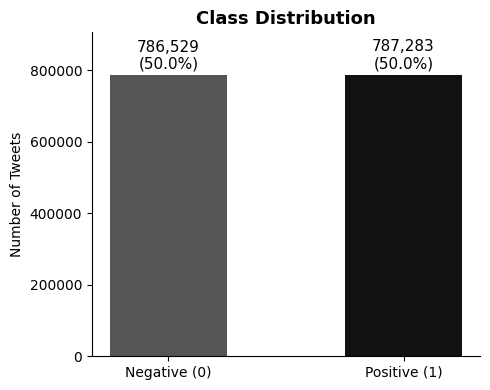

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['target'].value_counts().sort_index()
bars   = ax.bar(['Negative (0)', 'Positive (1)'],
                counts.values, color=['#555555', '#111111'], width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8000,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Tweets')
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

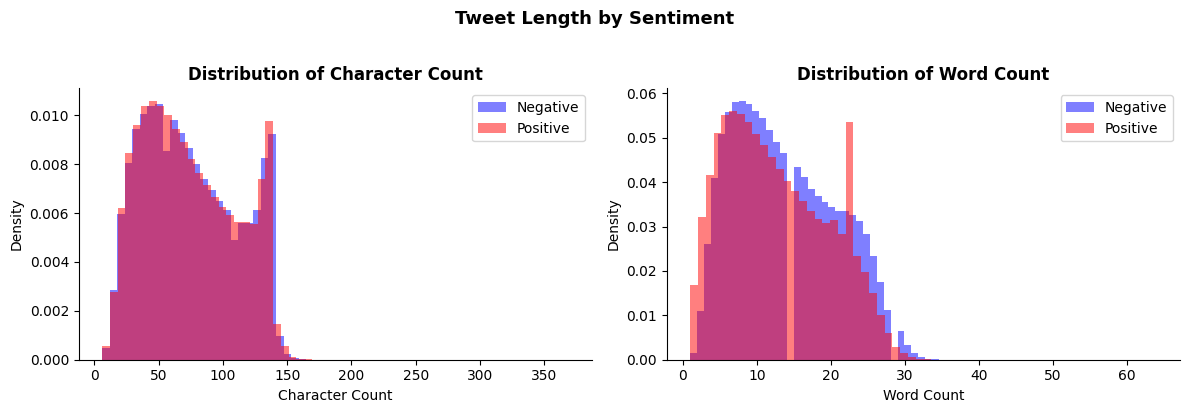

        char_len                                               word_len  \
           count   mean    std  min   25%   50%    75%    max     count   
target                                                                    
0       786529.0  75.11  36.34  6.0  45.0  70.0  105.0  359.0  786529.0   
1       787283.0  74.31  35.82  6.0  44.0  69.0  103.0  369.0  787283.0   

                                                 
         mean   std  min  25%   50%   75%   max  
target                                           
0       13.73  7.00  1.0  8.0  13.0  19.0  57.0  
1       12.86  6.77  1.0  7.0  12.0  18.0  64.0  


In [12]:
df['char_len'] = df['text'].apply(len)
df['word_len'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (col, label) in enumerate([('char_len', 'Character Count'),
                                    ('word_len',  'Word Count')]):
    for val, lbl, color in [(0, 'Negative', 'blue'), (1, 'Positive', 'red')]:
        axes[i].hist(df[df['target'] == val][col],
                     bins=60, alpha=0.5, label=lbl,
                     density=True, color=color)
    axes[i].set_title(f'Distribution of {label}', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('Tweet Length by Sentiment', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_02_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('target')[['char_len', 'word_len']].describe().round(2))

In [13]:
q_high = df['word_len'].quantile(0.99)

very_short = df[df['word_len'] <= 2]
very_long  = df[df['word_len'] >= q_high]

print(f"Very short tweets (≤2 words)          : {len(very_short):,} "
      f"({len(very_short)/len(df)*100:.2f}%)")
print(f"Very long tweets  (≥99th pct={q_high:.0f} words): {len(very_long):,} "
      f"({len(very_long)/len(df)*100:.2f}%)")

print("\nSample very short:")
print(very_short['text'].sample(5, random_state=42).values)
print("\nSample very long:")
print(very_long['text'].sample(5, random_state=42).values)

Very short tweets (≤2 words)          : 22,965 (1.46%)
Very long tweets  (≥99th pct=28 words): 26,414 (1.68%)

Sample very short:
['@shayboogs thx ' '@joooline Yeah ' 'picture '
 ' awesome  http://twitpic.com/6ikhd' 'history cao ']

Sample very long:
["@Iam_Angela Hey.Saw ur messages. I was trying to talk to u last night. I was going to DM u then I noticed u don't follow me  Need to talk?"
 "Oh holy hell, my pass expired in January!! ARGH. I will have to make the next one. Want to hear a serious problem? I've never been to CA "
 'huh i thought my 6am shower would have woken some1 up but i still hear them snoring lol o well guess ill go to bed work 2-11  |&lt;ay-|3ee'
 "American idol is like 2.5 weeks away and I think I'm goon go for it For the 13th time  I guess never give up on what u want!!!"
 'I desperately miss my blue tooth! I wish i could find the charger. I must have left in Orlando.. too bad no one there will call me back ']


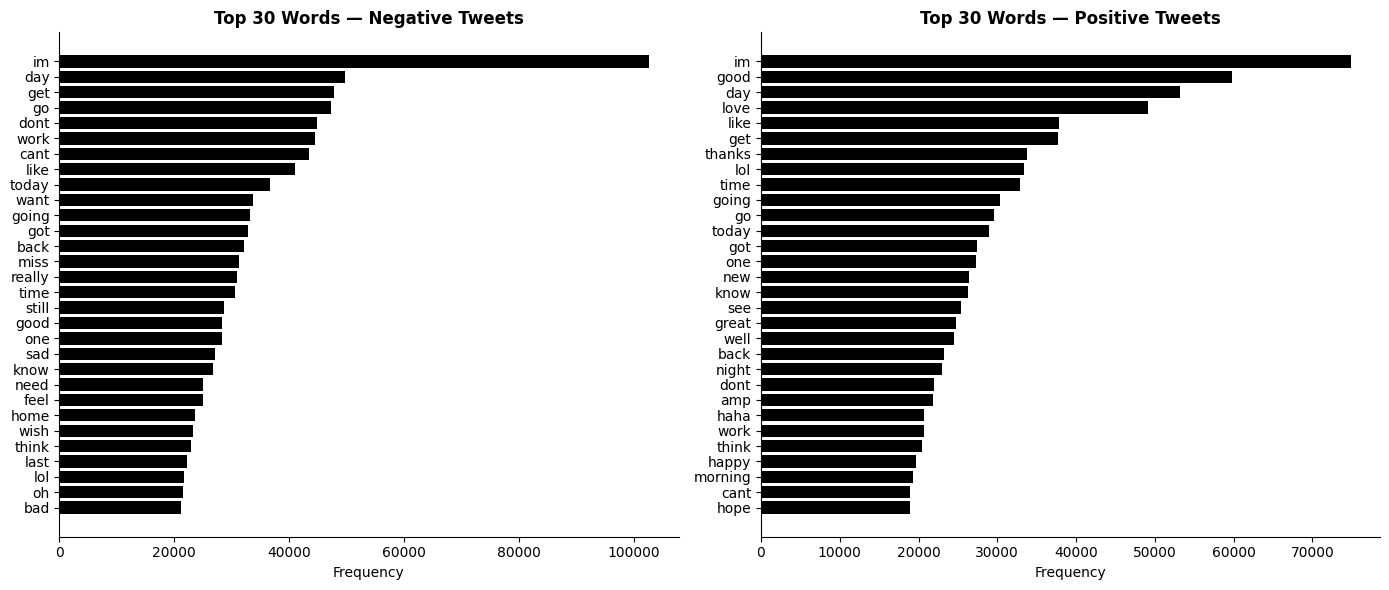

In [14]:
def top_words(series, n=30):
    all_words = ' '.join(series).split()
    return Counter(all_words).most_common(n)

top_neg = top_words(df[df['target'] == 0]['clean_text'])
top_pos = top_words(df[df['target'] == 1]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, top, title in zip(axes,
                           [top_neg, top_pos],
                           ['Negative Tweets', 'Positive Tweets']):
    words, counts = zip(*top)
    y_pos = range(len(words))
    ax.barh(y_pos, counts, color='black', align='center')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f'Top 30 Words — {title}', fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_03_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

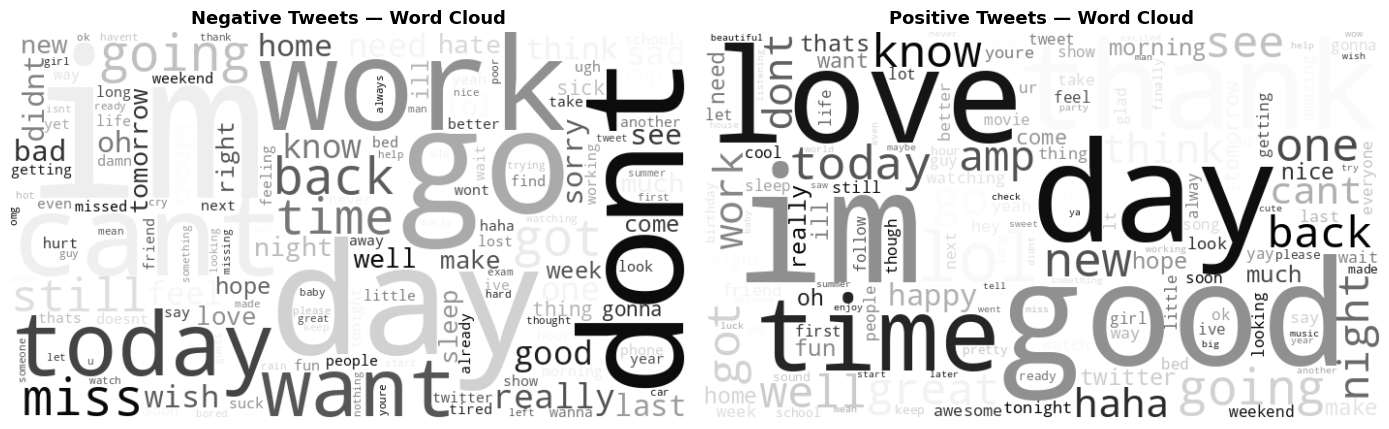

In [15]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, val, title in zip(axes, [0, 1], ['Negative', 'Positive']):
    corpus = ' '.join(
        df[df['target'] == val]['clean_text'].sample(50_000, random_state=42))
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greys', max_words=150,
                   collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{title} Tweets — Word Cloud',
                 fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('eda_04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

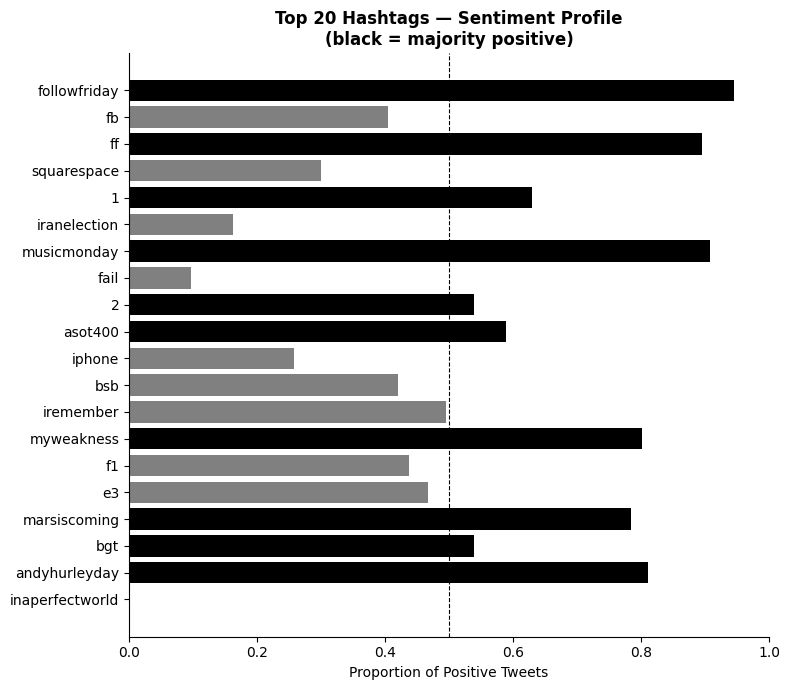

                 count  pos_rate
hashtag                         
followfriday      2630     0.945
fb                1774     0.405
ff                 977     0.896
squarespace        933     0.300
1                  515     0.629
iranelection       488     0.162
musicmonday        421     0.907
fail               363     0.096
2                  341     0.540
asot400            333     0.589
iphone             315     0.257
bsb                297     0.421
iremember          293     0.495
myweakness         268     0.802
f1                 258     0.438
e3                 257     0.467
marsiscoming       251     0.785
bgt                245     0.539
andyhurleyday      185     0.811
inaperfectworld    182     0.000


In [16]:
def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text).lower())

df['hashtags']      = df['text'].apply(extract_hashtags)
df['hashtag_count'] = df['hashtags'].apply(len)

hashtag_rows = [
    {'hashtag': tag, 'target': row['target']}
    for _, row in df[df['hashtag_count'] > 0].iterrows()
    for tag in row['hashtags']
]
ht_df = pd.DataFrame(hashtag_rows)

top_tags = ht_df['hashtag'].value_counts().head(20).index.tolist()
ht_top   = ht_df[ht_df['hashtag'].isin(top_tags)]

ht_pivot = ht_top.groupby('hashtag')['target'].agg(['sum', 'count'])
ht_pivot['pos_rate'] = ht_pivot['sum'] / ht_pivot['count']
ht_pivot = ht_pivot.sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['black' if r >= 0.5 else 'gray' for r in ht_pivot['pos_rate']]
ax.barh(ht_pivot.index, ht_pivot['pos_rate'], color=colors)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Proportion of Positive Tweets')
ax.set_title('Top 20 Hashtags — Sentiment Profile\n'
             '(black = majority positive)', fontweight='bold')
ax.set_xlim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_05_hashtag_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(ht_pivot[['count', 'pos_rate']].sort_values('count', ascending=False).round(3))

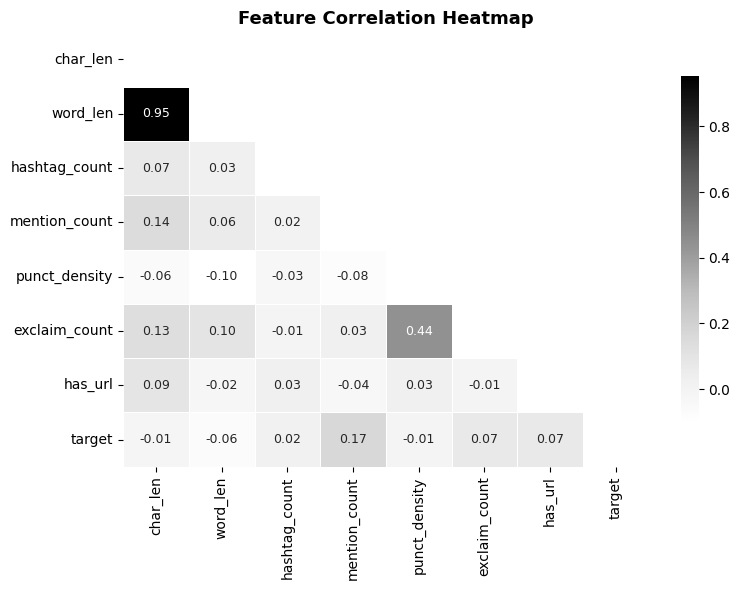

In [17]:
df['mention_count'] = df['text'].apply(
    lambda x: len(re.findall(r'@\w+', x)))
df['punct_density'] = df['text'].apply(
    lambda x: sum(1 for c in x if c in '!?.') / max(len(x), 1))
df['has_url']       = df['text'].apply(
    lambda x: int(bool(re.search(r'http\S+|www\S+', x))))
df['exclaim_count'] = df['text'].apply(lambda x: x.count('!'))

feature_cols = ['char_len', 'word_len', 'hashtag_count', 'mention_count',
                'punct_density', 'exclaim_count', 'has_url', 'target']
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Greys',
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df_model = df[df['clean_text'].str.strip() != ''].copy()
df_model = df_model[['clean_text', 'target', 'char_len', 'word_len',
                      'hashtag_count', 'mention_count', 'punct_density',
                      'exclaim_count', 'has_url']]
df_model = df_model.reset_index(drop=True)

df_model.to_csv('sentiment140_cleaned.csv', index=False)
print(f"Saved: {df_model.shape}")
df_model.head()

Saved: (1573812, 9)


,clean_text,target,char_len,word_len,hashtag_count,mention_count,punct_density,exclaim_count,has_url
0,upset cant update facebook texting might cry r...,0,111,21,0,0,0.045045,1,0
1,dived many time ball managed save rest go bound,0,89,18,0,1,0.011236,0,0
2,whole body feel itchy like fire,0,47,10,0,0,0.000000,0,0
3,behaving im mad cant see,0,111,21,0,1,0.036036,0,0
4,whole crew,0,29,5,0,1,0.000000,0,0


## Phase 3 (continued): Feature Engineering & Vectorisation

We build the final feature matrix by combining:
1. **TF-IDF features** (20,000 unigrams + bigrams, sublinear TF scaling) — captures word-level semantics
2. **Chi² feature selection** — retains the most discriminative TF-IDF terms
3. **7 engineered features** — char_len, word_len, hashtag_count, mention_count,
   punct_density, exclaim_count, has_url — capture structural tweet properties

All features are scaled and stacked into a single sparse matrix for modelling.

In [19]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import re
import os
import time

df_model = pd.read_csv('sentiment140_cleaned.csv')
df_model['clean_text'] = df_model['clean_text'].fillna('').astype(str)

# Ensure target is 0/1 (safe to run even if already remapped)
df_model['target'] = df_model['target'].map({0: 0, 4: 1}).fillna(df_model['target']).astype(int)

print(df_model.shape)
print(df_model['target'].value_counts())

(1573812, 9)
target
1    787283
0    786529
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

df_sample = df_model.groupby('target', group_keys=False).apply(
    lambda x: x.sample(50_000, random_state=42)
).reset_index(drop=True)

print(f"Sample size: {len(df_sample):,}")
print(df_sample['target'].value_counts())

X_raw = df_sample['clean_text']
y     = df_sample['target']

ENG_COLS = ['char_len', 'word_len', 'hashtag_count',
            'mention_count', 'punct_density', 'exclaim_count', 'has_url']

X_train_raw, X_temp_raw, y_train, y_temp, eng_train, eng_temp = train_test_split(
    X_raw, y, df_sample[ENG_COLS],
    test_size=0.30, random_state=42, stratify=y)

X_val_raw, X_test_raw, y_val, y_test, eng_val, eng_test = train_test_split(
    X_temp_raw, y_temp, eng_temp,
    test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nTrain : {len(X_train_raw):,}")
print(f"Val   : {len(X_val_raw):,}")
print(f"Test  : {len(X_test_raw):,}")

Sample size: 100,000
target
0    50000
1    50000
Name: count, dtype: int64

Train : 70,000
Val   : 15,000
Test  : 15,000


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20_000,   # matches real vocab on 70k tweets
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # log(1+tf) dampens high-freq terms
    min_df=3,              # drop terms in fewer than 3 docs
    max_df=0.90,           # drop terms in >90% of docs
    strip_accents='unicode',
    analyzer='word',
)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf   = tfidf.transform(X_val_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print(f"Vocab size         : {len(tfidf.vocabulary_):,}")
print(f"Train matrix shape : {X_train_tfidf.shape}")

Vocab size         : 20,000
Train matrix shape : (70000, 20000)


In [22]:
from sklearn.feature_selection import SelectKBest, chi2

# k='all' — vocab is already small, keep everything
selector = SelectKBest(chi2, k='all')
X_train_tfidf_sel = selector.fit_transform(X_train_tfidf, y_train)
X_val_tfidf_sel   = selector.transform(X_val_tfidf)
X_test_tfidf_sel  = selector.transform(X_test_tfidf)

print(f"Feature matrix shape: {X_train_tfidf_sel.shape}")

# Top 20 features + direction (positive-leaning vs negative-leaning)
feature_names = np.array(tfidf.get_feature_names_out())
selected_names = feature_names
chi2_scores    = selector.scores_
top20_idx      = np.argsort(chi2_scores)[-20:][::-1]

pos_mask = y_train.values == 1
neg_mask = y_train.values == 0
pos_mean = np.asarray(X_train_tfidf_sel[pos_mask].mean(axis=0)).flatten()
neg_mean = np.asarray(X_train_tfidf_sel[neg_mask].mean(axis=0)).flatten()

print(f"\n{'Feature':<22} {'Chi²':>8}  Direction")
print("-" * 45)
for idx in top20_idx:
    direction = "→ POSITIVE" if pos_mean[idx] > neg_mean[idx] else "→ NEGATIVE"
    print(f"{selected_names[idx]:<22} {chi2_scores[idx]:>8.1f}  {direction}")

Feature matrix shape: (70000, 20000)

Feature                    Chi²  Direction
---------------------------------------------
thanks                    340.2  → POSITIVE
sad                       278.6  → NEGATIVE
miss                      259.6  → NEGATIVE
thank                     199.4  → POSITIVE
love                      195.7  → POSITIVE
hate                      153.7  → NEGATIVE
wish                      135.4  → NEGATIVE
good                      134.4  → POSITIVE
suck                      130.3  → NEGATIVE
sick                      125.2  → NEGATIVE
sorry                     123.8  → NEGATIVE
hurt                      120.6  → NEGATIVE
great                     120.5  → POSITIVE
bad                       103.4  → NEGATIVE
welcome                   103.1  → POSITIVE
awesome                   101.8  → POSITIVE
ugh                        97.9  → NEGATIVE
happy                      97.7  → POSITIVE
dont                       83.8  → NEGATIVE
cant                       83.3  → NE

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)   # sparse-safe
eng_train_scaled = scaler.fit_transform(eng_train)
eng_val_scaled   = scaler.transform(eng_val)
eng_test_scaled  = scaler.transform(eng_test)

X_train = sp.hstack([X_train_tfidf_sel, eng_train_scaled])
X_val   = sp.hstack([X_val_tfidf_sel,   eng_val_scaled])
X_test  = sp.hstack([X_test_tfidf_sel,  eng_test_scaled])

print(f"Final feature matrix (train): {X_train.shape}")

Final feature matrix (train): (70000, 20007)


## Phase 4: Modelling — Classification

We train and compare six classifiers on the combined feature matrix.
A 70/15/15 train/validation/test split is used with stratification to preserve class balance.

**Hyperparameter rationale:**
- `LogisticRegression C=1 / C=5`: C controls regularisation strength; we compare both to check
  whether relaxing the penalty improves generalisation.
- `LinearSVC C=1`: Fast linear classifier; strong baseline for text classification.
- `SGDClassifier`: Online learning variant — efficient on large sparse matrices.
- `RandomForest n_estimators=300`: Ensemble size chosen to balance variance reduction and runtime.
- `DecisionTree max_depth=20`: Depth capped to prevent overfitting on the high-dimensional TF-IDF space.

Models are selected based on macro F1 on the validation set.

In [24]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm          import LinearSVC
from sklearn.ensemble     import RandomForestClassifier
from sklearn.tree         import DecisionTreeClassifier
from sklearn.metrics      import f1_score
import joblib

models = {
    'Logistic Regression (C=1)': LogisticRegression(C=1.0, max_iter=1000,
                                                     solver='lbfgs', n_jobs=-1),
    'Logistic Regression (C=5)': LogisticRegression(C=5.0, max_iter=1000,
                                                     solver='lbfgs', n_jobs=-1),
    'SVM (LinearSVC)':           LinearSVC(C=1.0, max_iter=3000),
    'SGD Classifier':            SGDClassifier(loss='modified_huber', alpha=1e-4,
                                               max_iter=100, random_state=42,
                                               n_jobs=-1),
    'Random Forest':             RandomForestClassifier(n_estimators=300,
                                                        n_jobs=-1, random_state=42),
    'Decision Tree':             DecisionTreeClassifier(max_depth=20, random_state=42),
}

results = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    val_f1  = f1_score(y_val, model.predict(X_val), average='macro')
    results[name] = {'model': model, 'val_f1': val_f1, 'train_time': elapsed}
    print(f"{name:<35}  val F1={val_f1:.4f}  ({elapsed:.1f}s)")

os.makedirs('models', exist_ok=True)
for name, res in results.items():
    fname = re.sub(r'[^a-z0-9]', '_', name.lower()) + '.joblib'
    joblib.dump(res['model'], f'models/{fname}')
joblib.dump(tfidf,    'models/tfidf_vectoriser.joblib')
joblib.dump(selector, 'models/chi2_selector.joblib')
joblib.dump(scaler,   'models/scaler.joblib')
print("\nAll models saved to models/")


Logistic Regression (C=1)            val F1=0.7734  (11.6s)
Logistic Regression (C=5)            val F1=0.7633  (8.6s)
SVM (LinearSVC)                      val F1=0.7593  (2.3s)
SGD Classifier                       val F1=0.7342  (0.9s)
Random Forest                        val F1=0.7463  (857.9s)
Decision Tree                        val F1=0.6533  (7.0s)

All models saved to models/


In [91]:
# Hyperparameter summary table
import pandas as pd

summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model': name,
        'Val F1 (macro)': round(res['val_f1'], 4),
        'Train Time (s)': round(res['train_time'], 1)
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Val F1 (macro)', ascending=False)
print("=== Model Performance Summary ===")
print(summary_df.to_string(index=False))

=== Model Performance Summary ===
                    Model  Val F1 (macro)  Train Time (s)
Logistic Regression (C=1)          0.7734            11.6
Logistic Regression (C=5)          0.7633             8.6
          SVM (LinearSVC)          0.7593             2.3
            Random Forest          0.7463           857.9
           SGD Classifier          0.7342             0.9
            Decision Tree          0.6533             7.0


In [25]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              RocCurveDisplay)
import matplotlib.pyplot as plt

best_name  = max(results, key=lambda k: results[k]['val_f1'])
best_model = results[best_name]['model']
print(f"Best model : {best_name}")
print(f"Val F1     : {results[best_name]['val_f1']:.4f}\n")

y_test_pred = best_model.predict(X_test)

if hasattr(best_model, 'predict_proba'):
    y_test_prob = best_model.predict_proba(X_test)[:, 1]
else:
    y_test_prob = best_model.decision_function(X_test)

print(classification_report(y_test, y_test_pred,
                             target_names=['Negative', 'Positive']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_test_prob):.4f}")

Best model : Logistic Regression (C=1)
Val F1     : 0.7734

              precision    recall  f1-score   support

    Negative       0.78      0.76      0.77      7500
    Positive       0.76      0.78      0.77      7500

    accuracy                           0.77     15000
   macro avg       0.77      0.77      0.77     15000
weighted avg       0.77      0.77      0.77     15000

ROC-AUC : 0.8503


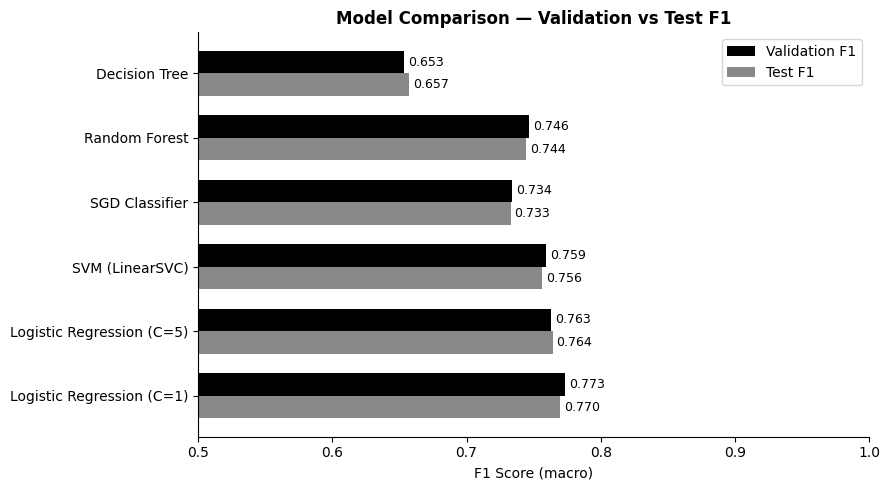

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
names    = list(results.keys())
val_f1s  = [results[n]['val_f1'] for n in names]
test_f1s = [f1_score(y_test, results[n]['model'].predict(X_test),
                     average='macro') for n in names]

x = np.arange(len(names))
w = 0.35
bars1 = ax.barh(x + w/2, val_f1s,  w, color='black',   label='Validation F1')
bars2 = ax.barh(x - w/2, test_f1s, w, color='#888888', label='Test F1')

ax.set_yticks(x)
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('F1 Score (macro)')
ax.set_title('Model Comparison — Validation vs Test F1', fontweight='bold')
ax.set_xlim(0.5, 1.0)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
for bar, val in list(zip(bars1, val_f1s)) + list(zip(bars2, test_f1s)):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('eval_01_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

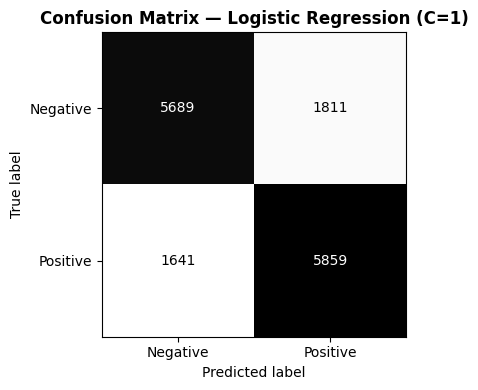

In [27]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Negative', 'Positive']).plot(
    ax=ax, colorbar=False, cmap='Greys')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('eval_02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

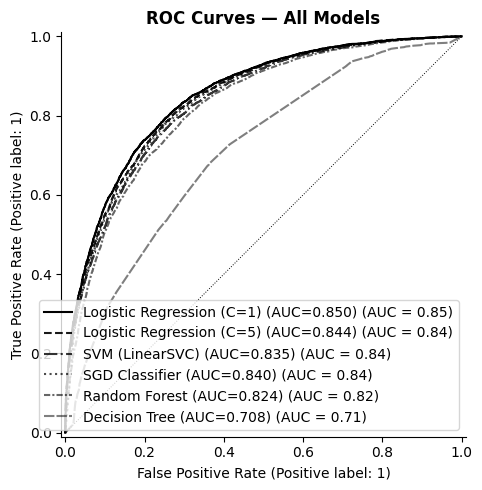

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
linestyles = ['-', '--', '-.', ':', (0,(3,1,1,1)), (0,(5,1))]

for (name, res), ls in zip(results.items(), linestyles):
    m      = res['model']
    scores = (m.predict_proba(X_test)[:, 1]
              if hasattr(m, 'predict_proba')
              else m.decision_function(X_test))
    auc = roc_auc_score(y_test, scores)
    RocCurveDisplay.from_predictions(
        y_test, scores, ax=ax,
        name=f'{name} (AUC={auc:.3f})',
        linestyle=ls, color='black',
        alpha=max(0.35, 1.0 - 0.1 * list(results).index(name)))

ax.plot([0, 1], [0, 1], 'k:', linewidth=0.7)
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eval_03_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 5: Evaluation

We evaluate the best model (selected by validation F1) on the held-out test set using:
- **Classification report** — precision, recall, F1 per class
- **ROC-AUC** — measures discriminative power across all thresholds
- **Confusion matrix** — visualises true/false positives and negatives
- **SHAP** — global feature importance and directional impact
- **LIME** — local explanations for individual tweet predictions

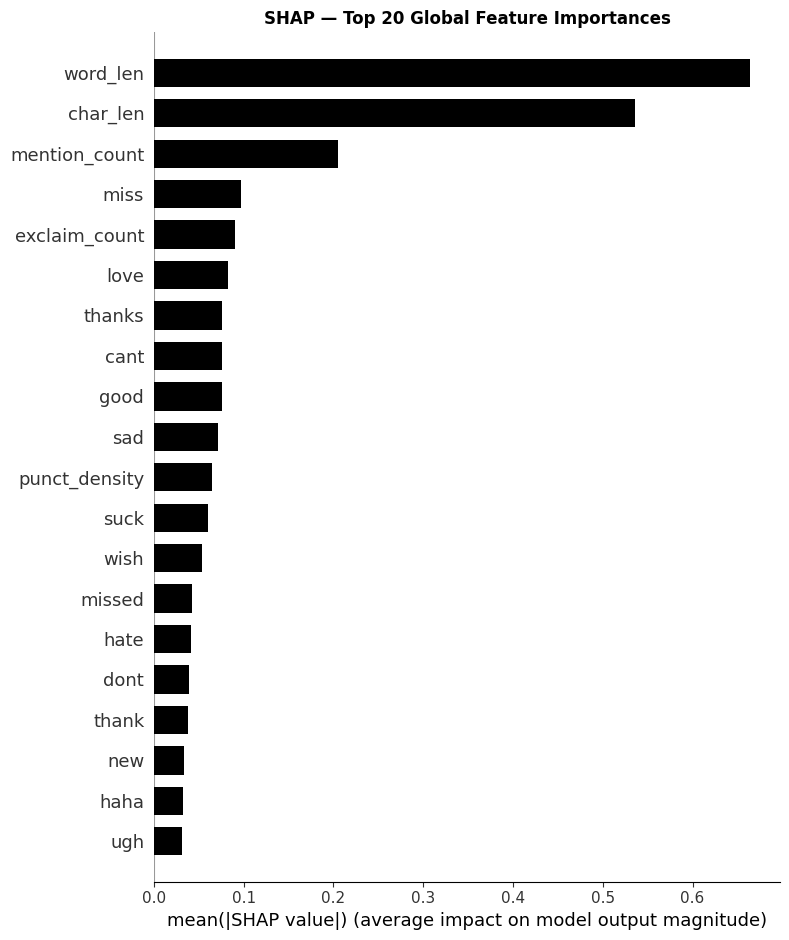

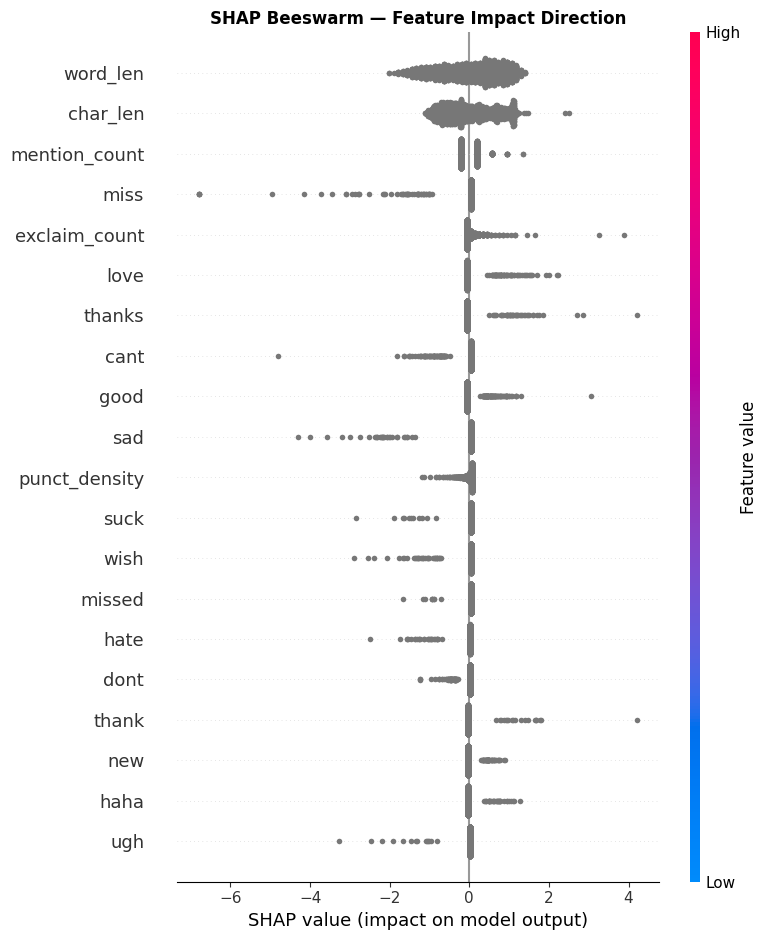

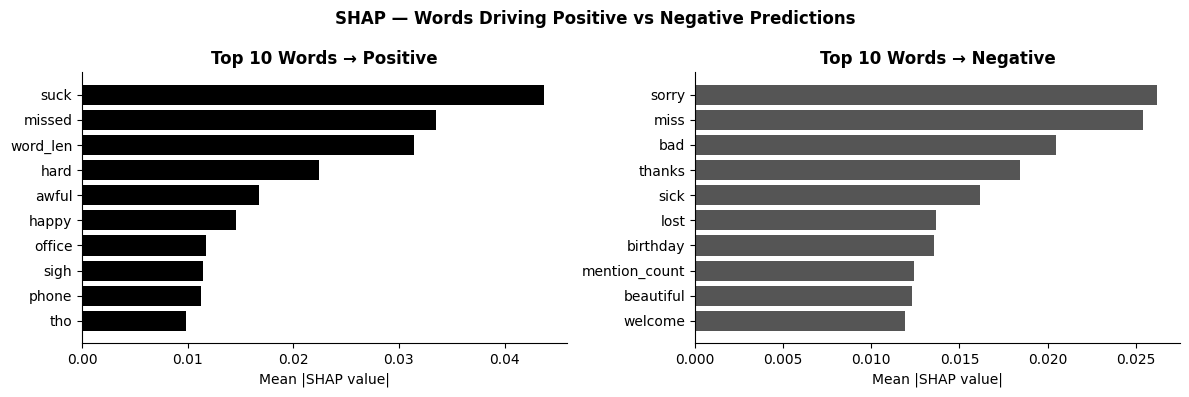

In [29]:
import shap

X_test_sample = X_test.tocsr()[:2000]

explainer   = shap.LinearExplainer(best_model, X_train)
shap_values = explainer.shap_values(X_test_sample)

all_feature_names = list(selected_names) + ENG_COLS

# Bar summary
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=all_feature_names,
                  max_display=20, plot_type='bar',
                  show=False, color='black')
plt.title('SHAP — Top 20 Global Feature Importances', fontweight='bold')
plt.tight_layout()
plt.savefig('eval_04_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm (direction + magnitude)
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=all_feature_names,
                  max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.savefig('eval_05_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Directional: top words pushing positive vs negative
mean_shap   = np.array(shap_values).mean(axis=0)
top_pos_idx = mean_shap.argsort()[-10:][::-1]
top_neg_idx = mean_shap.argsort()[:10]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, idx, title, color in [
    (axes[0], top_pos_idx, 'Top 10 Words → Positive', 'black'),
    (axes[1], top_neg_idx, 'Top 10 Words → Negative', '#555555')]:
    words  = [all_feature_names[i] for i in idx]
    values = [abs(mean_shap[i])    for i in idx]
    ax.barh(words[::-1], values[::-1], color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|')
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('SHAP — Words Driving Positive vs Negative Predictions',
             fontweight='bold')
plt.tight_layout()
plt.savefig('eval_06_shap_directional.png', dpi=150, bbox_inches='tight')
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Fitting text-only model for LIME...

[Correct Positive]
Tweet     : calvin klein one ad sooooo good check youtube
True      : Positive  |  Predicted : Positive
Top tokens:
  check                +0.1528  ↑ pos
  sooooo               -0.1370  ↓ neg
  good                 +0.1355  ↑ pos
  ad                   +0.0624  ↑ pos
  calvin               -0.0270  ↓ neg
  one                  -0.0267  ↓ neg
  youtube              -0.0167  ↓ neg
  klein                -0.0053  ↓ neg


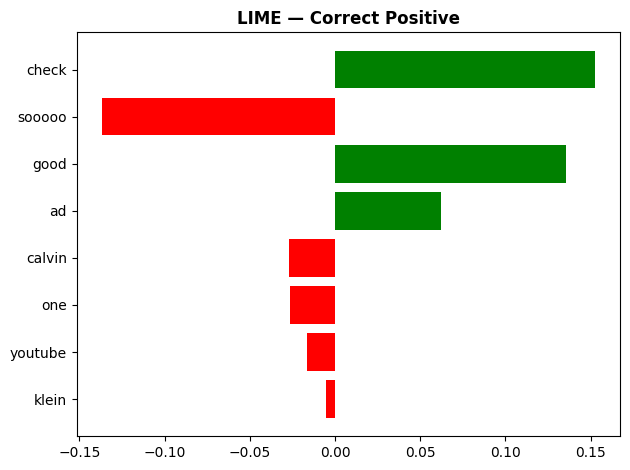


[Correct Negative]
Tweet     : gonna chill tasha step mom wouldnt let sister come poor kidd
True      : Negative  |  Predicted : Negative
Top tokens:
  poor                 -0.3178  ↓ neg
  chill                +0.1807  ↑ pos
  wouldnt              -0.1402  ↓ neg
  step                 +0.0887  ↑ pos
  sister               +0.0613  ↑ pos
  mom                  -0.0597  ↓ neg
  let                  +0.0203  ↑ pos
  gonna                +0.0175  ↑ pos
  kidd                 -0.0062  ↓ neg
  come                 -0.0059  ↓ neg


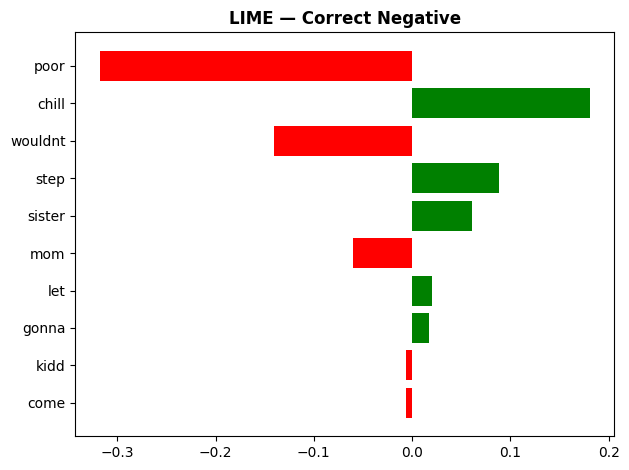


[Misclassified]
Tweet     : starting today im working everyday next day ill saturday sux sux sux
True      : Positive  |  Predicted : Negative
Top tokens:
  sux                  -0.2455  ↓ neg
  working              -0.0603  ↓ neg
  day                  -0.0396  ↓ neg
  next                 -0.0369  ↓ neg
  everyday             +0.0242  ↑ pos
  today                +0.0238  ↑ pos
  saturday             -0.0176  ↓ neg
  starting             +0.0158  ↑ pos
  ill                  +0.0130  ↑ pos
  im                   -0.0050  ↓ neg


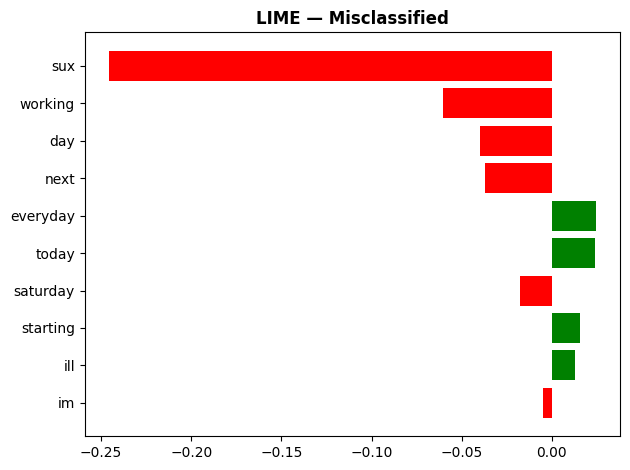

In [30]:
!pip install lime -q
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

# Text-only pipeline (LIME only perturbs text tokens)
text_only_pipeline = Pipeline([
    ('tfidf',    tfidf),
    ('selector', selector),
])

# Re-fit best model on TF-IDF-only features for LIME
print("Fitting text-only model for LIME...")
lime_model = type(best_model)(**best_model.get_params())

if not hasattr(lime_model, 'predict_proba'):
    lime_model = CalibratedClassifierCV(lime_model, cv=3)

lime_model.fit(X_train_tfidf_sel, y_train)

def lime_predict_proba(texts):
    X = text_only_pipeline.transform(texts)
    return lime_model.predict_proba(X)

lime_explainer = LimeTextExplainer(class_names=['Negative', 'Positive'])

X_test_raw_r = X_test_raw.reset_index(drop=True)
y_test_r     = y_test.reset_index(drop=True)
y_pred_all   = best_model.predict(X_test)

# Pick 1 correct positive, 1 correct negative, 1 misclassified
correct_pos = np.where((y_test_r == 1) & (y_pred_all == 1))[0]
correct_neg = np.where((y_test_r == 0) & (y_pred_all == 0))[0]
wrong       = np.where(y_test_r.values != y_pred_all)[0]

examples = {
    'Correct Positive': correct_pos[0],
    'Correct Negative': correct_neg[0],
    'Misclassified':    wrong[0],
}

for label, idx in examples.items():
    tweet    = X_test_raw_r[idx]
    true_lbl = 'Positive' if y_test_r[idx] == 1 else 'Negative'
    pred_lbl = 'Positive' if y_pred_all[idx] == 1 else 'Negative'

    exp = lime_explainer.explain_instance(
        tweet, lime_predict_proba,
        num_features=10, num_samples=300)

    print(f"\n{'='*55}")
    print(f"[{label}]")
    print(f"Tweet     : {tweet[:100]}")
    print(f"True      : {true_lbl}  |  Predicted : {pred_lbl}")
    print("Top tokens:")
    for feat, weight in exp.as_list():
        arrow = '↑ pos' if weight > 0 else '↓ neg'
        print(f"  {feat:<20} {weight:+.4f}  {arrow}")

    fig = exp.as_pyplot_figure()
    plt.title(f'LIME — {label}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'eval_07_lime_{label.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## Phase 4 (continued): Modelling — Regression Analysis

The course requires at least one regression technique. Here we apply regression to predict
sentiment probability using only the 7 engineered structural features.

This answers a different question from classification: *by how much* does each structural
feature shift sentiment probability? Ridge regression also handles multicollinearity between
correlated features (e.g. char_len and word_len).

Models compared: Linear Regression (baseline), Ridge (α=1.0), Lasso (α=0.001).
Evaluation: MSE, RMSE, R², and F1 after thresholding predictions at 0.5.

Model                        RMSE      R²   F1 (thresh=0.5)
------------------------------------------------------------
Linear Regression          0.4855  0.0571            0.6030
Ridge (α=1.0)              0.4855  0.0571            0.6030
Lasso (α=0.001)            0.4856  0.0567            0.6022


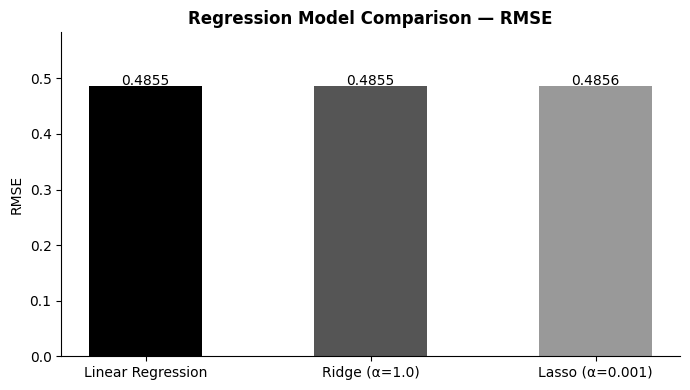

In [92]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# Use engineered features only (already available)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler as SS

ENG_COLS_REG = ['char_len', 'word_len', 'hashtag_count',
                'mention_count', 'punct_density', 'exclaim_count', 'has_url']

reg_df = df_model[ENG_COLS_REG + ['target']].dropna()
X_reg = reg_df[ENG_COLS_REG].values
y_reg = reg_df['target'].values.astype(float)

X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

ss = SS()
X_r_train_s = ss.fit_transform(X_r_train)
X_r_test_s  = ss.transform(X_r_test)

reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)':     Ridge(alpha=1.0),
    'Lasso (α=0.001)':   Lasso(alpha=0.001, max_iter=5000),
}

reg_results = {}
print(f"{'Model':<25} {'RMSE':>7} {'R²':>7} {'F1 (thresh=0.5)':>17}")
print("-" * 60)
for name, reg_model in reg_models.items():
    reg_model.fit(X_r_train_s, y_r_train)
    preds   = reg_model.predict(X_r_test_s)
    preds_c = np.clip(preds, 0, 1)
    rmse    = np.sqrt(mean_squared_error(y_r_test, preds_c))
    r2      = r2_score(y_r_test, preds_c)
    f1      = f1_score(y_r_test, (preds_c >= 0.5).astype(int), average='macro')
    reg_results[name] = {'rmse': rmse, 'r2': r2, 'f1': f1}
    print(f"{name:<25} {rmse:>7.4f} {r2:>7.4f} {f1:>17.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
names_r = list(reg_results.keys())
rmses   = [reg_results[n]['rmse'] for n in names_r]
ax.bar(names_r, rmses, color=['black', '#555555', '#999999'], width=0.5)
ax.set_ylabel('RMSE')
ax.set_title('Regression Model Comparison — RMSE', fontweight='bold')
ax.set_ylim(0, max(rmses) * 1.2)
for i, (bar, val) in enumerate(zip(ax.patches, rmses)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002, f'{val:.4f}',
            ha='center', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('regression_01_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Reducing dimensions with SVD...
Explained variance (100 components): 0.146

Computing elbow curve...
  k= 2  inertia=46,970  silhouette=0.0143
  k= 3  inertia=46,327  silhouette=0.0187
  k= 4  inertia=45,666  silhouette=0.0259
  k= 5  inertia=45,194  silhouette=0.0289
  k= 6  inertia=44,574  silhouette=0.0336
  k= 7  inertia=44,052  silhouette=0.0369
  k= 8  inertia=43,775  silhouette=0.0386
  k= 9  inertia=43,204  silhouette=0.0471
  k=10  inertia=42,882  silhouette=0.0454


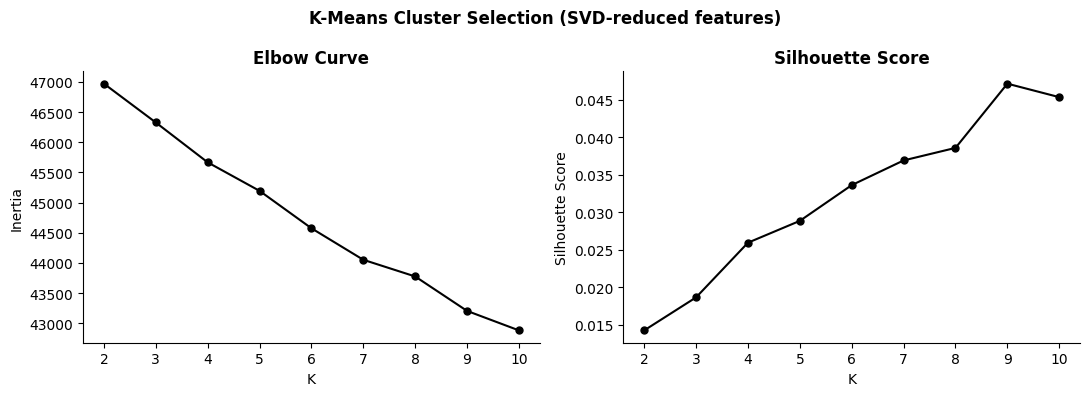

In [31]:
from sklearn.cluster       import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics       import silhouette_score
from sklearn.preprocessing import Normalizer

sample_size   = 50_000
idx_sample    = np.random.RandomState(42).choice(
                    len(X_train_raw), sample_size, replace=False)
X_cluster_raw = tfidf.transform(X_train_raw.iloc[idx_sample])
X_cluster_raw = selector.transform(X_cluster_raw)
y_cluster     = y_train.iloc[idx_sample].values

# Reduce to 100 SVD components + L2 normalise before clustering
print("Reducing dimensions with SVD...")
svd_cluster = TruncatedSVD(n_components=100, random_state=42)
normaliser  = Normalizer(copy=False)
X_cluster_reduced = normaliser.fit_transform(
    svd_cluster.fit_transform(X_cluster_raw))

print(f"Explained variance (100 components): "
      f"{svd_cluster.explained_variance_ratio_.sum():.3f}")

# Elbow + silhouette
print("\nComputing elbow curve...")
inertias, sil_scores = [], []
for k in range(2, 11):
    km = MiniBatchKMeans(n_clusters=k, random_state=42,
                         batch_size=5000, n_init=5)
    labels = km.fit_predict(X_cluster_reduced)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster_reduced, labels,
                           sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"  k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(2, 11), inertias,   'ko-', markersize=5)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(range(2, 11), sil_scores, 'ko-', markersize=5)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('K-Means Cluster Selection (SVD-reduced features)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_01_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

=== K-Means  K=3 ===

Cluster 0 (Positive) |  size=26,398  |  pos_rate=0.56
  Top terms: love, got, amp, like, time, cant, new, good, thanks, people

Cluster 1 (Neutral) |  size=18,403  |  pos_rate=0.44
  Top terms: day, get, go, going, want, know, lol, morning, home, night

Cluster 2 (Negative) |  size=5,199  |  pos_rate=0.42
  Top terms: im, work, back, im going, going, gonna, day, im sorry, go, get



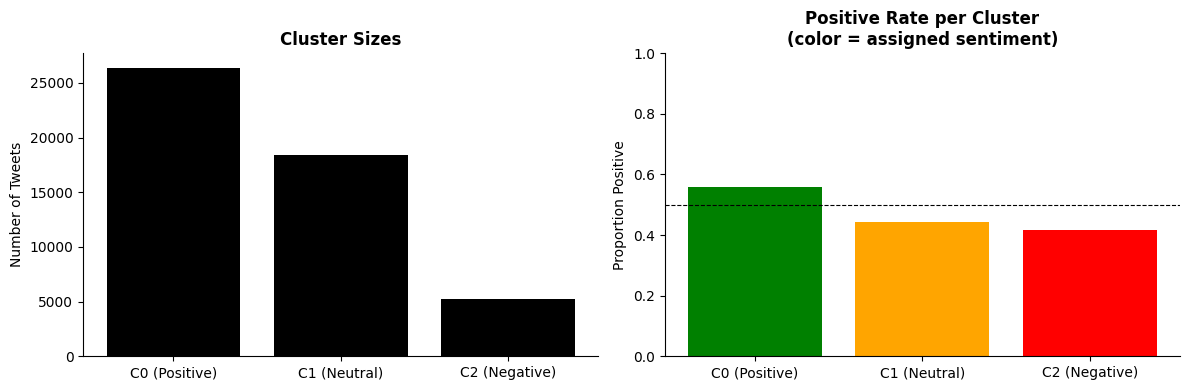

In [64]:
# @title Choose the number of clusters (BEST_K)
BEST_K = 3 # @param {type: "slider", min: 2, max: 10, step: 1}

# @title Define Neutral Sentiment Threshold
neutral_threshold = 0.058 # @param {type: "slider", min: 0.01, max: 0.2, step: 0.01}

km_final = MiniBatchKMeans(n_clusters=BEST_K, random_state=42,
                            batch_size=5000, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster_reduced)

# Project cluster centres back to vocab space for top terms
centers_vocab = svd_cluster.inverse_transform(km_final.cluster_centers_)

print(f"=== K-Means  K={BEST_K} ===\n")
cluster_summary = []
cluster_labels_map = {} # To store assigned sentiment label for each cluster ID

for c in range(BEST_K):
    mask      = cluster_labels == c
    size      = mask.sum()
    pos_rate  = y_cluster[mask].mean()   # correctly 0.0–1.0

    # Assign sentiment label based on pos_rate and threshold
    if (0.5 - neutral_threshold) < pos_rate < (0.5 + neutral_threshold):
        sentiment_label = "Neutral"
    elif pos_rate >= (0.5 + neutral_threshold):
        sentiment_label = "Positive"
    else:
        sentiment_label = "Negative"
    cluster_labels_map[c] = sentiment_label

    top_idx   = centers_vocab[c].argsort()[-10:][::-1]
    top_terms = selected_names[top_idx]
    cluster_summary.append((c, size, pos_rate, sentiment_label, top_terms))
    print(f"Cluster {c} ({sentiment_label}) |  size={size:,}  |  pos_rate={pos_rate:.2f}")
    print(f"  Top terms: {', '.join(top_terms)}\n")

# Bar charts: cluster sizes + sentiment lean
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
c_ids     = [r[0] for r in cluster_summary]
sizes     = [r[1] for r in cluster_summary]
pos_rates = [r[2] for r in cluster_summary]
sentiment_labels_for_plot = [r[3] for r in cluster_summary] # New list of labels

# Custom colors for sentiment labels
sentiment_colors = {
    "Negative": "red",
    "Neutral": "orange",
    "Positive": "green"
}
bar_colors_pos_rate = [sentiment_colors[label] for label in sentiment_labels_for_plot]


axes[0].bar([f'C{c} ({sentiment_labels_for_plot[i]})' for i, c in enumerate(c_ids)], sizes, color='black') # Update labels
axes[0].set_title('Cluster Sizes', fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
axes[0].spines[['top', 'right']].set_visible(False)

# Update colors for the sentiment bar plot
axes[1].bar([f'C{c} ({sentiment_labels_for_plot[i]})' for i, c in enumerate(c_ids)], pos_rates, color=bar_colors_pos_rate)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Positive Rate per Cluster\n(color = assigned sentiment)',
                   fontweight='bold')
axes[1].set_ylabel('Proportion Positive')
axes[1].set_ylim(0, 1)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('clustering_02_cluster_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Dashboard**

In [97]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import re
import string
import pandas as pd # Import pandas here for df_model usage

# NLTK imports and downloads (handle gracefully for Streamlit deployment)
import nltk
try:
    nltk.data.find('corpora/stopwords')
except Exception:
    nltk.download('stopwords', quiet=True)
try:
    nltk.data.find('corpora/wordnet')
except Exception:
    nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import scipy.sparse as sp

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# --- Utility functions (same as before) ---
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#(\w+)', r'\\1', text)             # keep hashtag word
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text).lower())

st.set_page_config(page_title="Twitter Sentiment Analysis Dashboard",
                   layout="wide")

# ---------------------------------------
# Load Model + Vectorizer + Selector + Scaler
# ---------------------------------------
MODEL_PATH = "models/logistic_regression__c_1_.joblib"
VECTORIZER_PATH = "models/tfidf_vectoriser.joblib"
SELECTOR_PATH = "models/chi2_selector.joblib"
SCALER_PATH = "models/scaler.joblib"
DF_MODEL_PATH = "sentiment140_cleaned.csv" # Path to cleaned data

try:
    model = joblib.load(MODEL_PATH)
    vectorizer = joblib.load(VECTORIZER_PATH)
    selector = joblib.load(SELECTOR_PATH)
    scaler = joblib.load(SCALER_PATH)
    df_model = pd.read_csv(DF_MODEL_PATH) # Load df_model here
    # Ensure target is 0/1 (safe to run even if already remapped)
    df_model['target'] = df_model['target'].map({0: 0, 4: 1}).fillna(df_model['target']).astype(int)


    # Load model evaluation metrics (hardcoded from previous output for simplicity)
    best_model_val_f1 = 0.7734
    best_model_test_f1 = 0.7698 # Using Logistic Regression (C=1) test F1 from output
    best_model_roc_auc = 0.8503 # Using Logistic Regression (C=1) ROC-AUC from output

except FileNotFoundError:
    st.error("Error: One or more required files (model, vectorizer, scaler, or data) not found. Please ensure 'models/' directory and 'sentiment140_cleaned.csv' exist.")
    st.stop()
except Exception as e:
    st.error(f"An error occurred during loading: {e}")
    st.stop()

# ---------------------------------------
# Header
# ---------------------------------------
st.title("🐦 Interactive Twitter Sentiment Analysis Dashboard")
st.markdown("""
This dashboard provides a comprehensive view of sentiment analysis on the **Sentiment140 dataset**,
showcasing **data insights, model performance, interpretability,** and offering **real-time tweet classification.**
""")

st.divider()

# Initialize session state for global filter
if 'global_sentiment_filter' not in st.session_state:
    st.session_state['global_sentiment_filter'] = 'All'

# ---------------------------------------
# SIDEBAR NAVIGATION & GLOBAL FILTER
# ---------------------------------------
st.sidebar.header("🚀 Navigate Project Stages")
section = st.sidebar.radio("",
                           ["1. Project Overview",
                            "2. EDA & Data Insights",
                            "3. Model Performance",
                            "4. Interpretability (LIME & SHAP)",
                            "5. Clustering Analysis",
                            "5b. Regression Analysis",# Renamed to be explicit
                            "6. Real-Time Sentiment Predictor",
                            "7. Business Insights"]) # New Section

st.sidebar.markdown("---")
st.sidebar.markdown(f"**Model in Use:** \
    <span style=\"color: #1a73e8; font-weight: bold;\">Logistic Regression (C=1)</span>",
    unsafe_allow_html=True)
st.sidebar.markdown("**Feature Engineering:** TF-IDF + 7 Engineered Features")

st.sidebar.markdown("---")
st.sidebar.subheader("Global Data Filter")
st.session_state['global_sentiment_filter'] = st.sidebar.radio(
    "Filter by Sentiment:",
    ('All', 'Positive', 'Negative'),
    key='sentiment_filter'
)
st.sidebar.markdown(f"**Current Filter:** {st.session_state['global_sentiment_filter']}")


# ---------------------------------------
# 1. Project Overview
# ---------------------------------------
if section == "1. Project Overview":
    st.header("✨ Project Overview: From Raw Tweets to Sentiment Prediction")
    st.markdown("""
    This project aims to classify the sentiment of tweets as either **positive (1)** or **negative (0)**.
    We started with a large dataset of 1.6 million tweets and built a robust machine learning pipeline.

    Here's a breakdown of the key steps:

    *   **Data Loading & Preprocessing**: Downloaded the Sentiment140 dataset, remapped target labels, and handled duplicates.
    *   **Text Cleaning**: Applied techniques like lowercasing, URL/mention removal, lemmatization, and stop-word filtering to prepare tweet text.
    *   **Exploratory Data Analysis (EDA)**: Visualized class distribution, tweet lengths, top words, and hashtag sentiment to understand the data.
    *   **Feature Engineering**: Created numerical features from raw text using TF-IDF and engineered additional features like character/word counts, hashtag counts, etc.
    *   **Feature Selection & Scaling**: Used Chi-squared for TF-IDF feature selection and StandardScaler for numerical features.
    *   **Model Training**: Trained and compared various classification models (Logistic Regression, SVM, Random Forest, etc.).
    *   **Model Evaluation**: Assessed model performance using metrics like F1-score, Confusion Matrix, and ROC curves.
    *   **Model Interpretability**: Employed SHAP and LIME to understand global feature importances and explain individual predictions.
    *   **Clustering**: Explored tweet clusters in a reduced dimension space to uncover natural groupings.
    *   **Deployment**: Built this interactive Streamlit dashboard to demonstrate the solution!
    """)


# ---------------------------------------
# 2. EDA & Data Insights (Mining Technique 1)
# ---------------------------------------
elif section == "2. EDA & Data Insights":
    st.header("📊 Data Mining Technique 1: Exploratory Data Analysis & Feature Engineering")
    st.markdown("""
    Understanding the dataset is crucial. These visualizations reveal key characteristics of the tweets and their sentiments,
    as well as insights gained from engineered features.
    """)

    # Apply global filter for dynamic plots
    filtered_df = df_model.copy()
    if st.session_state['global_sentiment_filter'] == 'Positive':
        filtered_df = filtered_df[filtered_df['target'] == 1]
    elif st.session_state['global_sentiment_filter'] == 'Negative':
        filtered_df = filtered_df[filtered_df['target'] == 0]

    st.subheader("Interactive Sentiment Class Distribution")
    st.info(f"This interactive chart shows the distribution of tweets by sentiment, affected by the '{st.session_state['global_sentiment_filter']}' filter.")

    if not filtered_df.empty:
        # Remap target for display
        display_df = filtered_df['target'].map({0: 'Negative', 1: 'Positive'}).value_counts().reset_index()
        display_df.columns = ['Sentiment', 'Count']
        st.bar_chart(display_df.set_index('Sentiment'))
    else:
        st.warning("No data to display for the current filter selection.")


    st.subheader("Tweet Length Distributions")
    st.info("We analyzed character and word counts to see if tweet length correlates with sentiment.")
    if os.path.exists("eda_02_length_distributions.png"):
        st.image("eda_02_length_distributions.png", caption="Distribution of Tweet Lengths by Sentiment")
    else:
        st.warning("Tweet length distribution plot not found.")

    st.subheader("Top Words by Sentiment")
    st.info("These bar charts highlight the most frequent words in negative vs. positive tweets after cleaning.")
    if os.path.exists("eda_03_top_words.png"):
        st.image("eda_03_top_words.png", caption="Top 30 Words in Negative and Positive Tweets")
    else:
        st.warning("Top words plot not found.")

    st.subheader("Word Clouds")
    st.info("Visual representation of word frequency, where larger words appear more often in that sentiment category.")
    if os.path.exists("eda_04_wordclouds.png"):
        st.image("eda_04_wordclouds.png", caption="Word Clouds for Negative and Positive Tweets")
    else:
        st.warning("Word cloud image not found.")

    st.subheader("Hashtag Sentiment Profile")
    st.info("Examining the sentiment associated with popular hashtags.")
    if os.path.exists("eda_05_hashtag_sentiment.png"):
        st.image("eda_05_hashtag_sentiment.png", caption="Top 20 Hashtags by Sentiment Profile")
    else:
        st.warning("Hashtag sentiment plot not found.")

    st.subheader("Feature Correlation Heatmap")
    st.info("A heatmap showing the relationships between various engineered features.")
    if os.path.exists("eda_06_correlation_heatmap.png"):
        st.image("eda_06_correlation_heatmap.png", caption="Feature Correlation Heatmap")
    else:
        st.warning("Correlation heatmap not found.")


# ---------------------------------------
# 3. Model Performance (Mining Technique 2)
# ---------------------------------------
elif section == "3. Model Performance":
    st.header("📈 Data Mining Technique 2: Model Training & Evaluation")
    st.markdown("""
    After training various models, we rigorously evaluated their performance on unseen test data.
    Our best performing model was **Logistic Regression (C=1)**.
    """)

    st.subheader("Key Metrics for Best Model")
    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric(label="Validation F1 Score", value=f"{best_model_val_f1:.4f}")
    with col2:
        st.metric(label="Test F1 Score", value=f"{best_model_test_f1:.4f}")
    with col3:
        st.metric(label="Test ROC-AUC Score", value=f"{best_model_roc_auc:.4f}")

    st.subheader("Model Comparison")
    st.info("Comparison of F1 scores across different models on validation and test sets.")
    if os.path.exists("eval_01_model_comparison.png"):
        st.image("eval_01_model_comparison.png", caption="Model Comparison — Validation vs Test F1")
    else:
        st.warning("Model comparison plot not found.")

    st.subheader("Confusion Matrix")
    st.info("Visualizing the correct and incorrect predictions made by the best model.")
    if os.path.exists("eval_02_confusion_matrix.png"):
        st.image("eval_02_confusion_matrix.png", caption="Confusion Matrix — Logistic Regression (C=1)")
    else:
        st.warning("Confusion matrix not found.")

    st.subheader("ROC Curves")
    st.info("Receiver Operating Characteristic curves for all models, showing their discriminative power.")
    if os.path.exists("eval_03_roc_curves.png"):
        st.image("eval_03_roc_curves.png", caption="ROC Curves — All Models")
    else:
        st.warning("ROC curves plot not found.")


# ---------------------------------------
# 4. Interpretability (LIME & SHAP) (Mining Technique 3)
# ---------------------------------------
elif section == "4. Interpretability (LIME & SHAP)":
    st.header("💡 Data Mining Technique 3: Model Interpretability (LIME & SHAP)")
    st.markdown("""
    Understanding model predictions is as important as the predictions themselves. We used two powerful interpretability techniques:

    *   **SHAP (SHapley Additive exPlanations)**: Provides global insights into feature importance and how features influence predictions.
    *   **LIME (Local Interpretable Model-agnostic Explanations)**: Explains individual predictions by perturbing the input and observing changes.
    """)

    st.subheader("SHAP: Global Feature Importances")
    st.info("These plots show which features generally contribute most to positive or negative sentiment predictions across the dataset.")

    if os.path.exists("eval_04_shap_global.png"):
        st.image("eval_04_shap_global.png", caption="SHAP — Top 20 Global Feature Importances")
    else:
        st.warning("SHAP global importance plot not found.")

    if os.path.exists("eval_05_shap_beeswarm.png"):
        st.image("eval_05_shap_beeswarm.png", caption="SHAP Beeswarm — Feature Impact Direction")
    else:
        st.warning("SHAP beeswarm plot not found.")

    if os.path.exists("eval_06_shap_directional.png"):
        st.image("eval_06_shap_directional.png", caption="SHAP — Words Driving Positive vs Negative Predictions")
    else:
        st.warning("SHAP directional words plot not found.")


    st.subheader("LIME: Local Prediction Explanations")
    st.info("LIME helps us understand why a specific tweet was classified as positive or negative by highlighting the most influential words in that particular tweet.")
    st.markdown("Here are examples of LIME explanations for different prediction scenarios:")

    col1, col2, col3 = st.columns(3)
    with col1:
        if os.path.exists("eval_07_lime_correct_positive.png"):
            st.image("eval_07_lime_correct_positive.png", caption="LIME Explanation: Correctly Classified Positive Tweet")
        else:
            st.warning("LIME correct positive plot not found.")
    with col2:
        if os.path.exists("eval_07_lime_correct_negative.png"):
            st.image("eval_07_lime_correct_negative.png", caption="LIME Explanation: Correctly Classified Negative Tweet")
        else:
            st.warning("LIME correct negative plot not found.")
    with col3:
        if os.path.exists("eval_07_lime_misclassified.png"):
            st.image("eval_07_lime_misclassified.png", caption="LIME Explanation: Misclassified Tweet")
        else:
            st.warning("LIME misclassified plot not found.")

# ---------------------------------------
# 5. Clustering Analysis (Mining Technique 4)
# ---------------------------------------
elif section == "5. Clustering Analysis":
    st.header("🔍 Data Mining Technique 4: Unsupervised Clustering Analysis")
    st.markdown("""
    We used K-Means clustering to identify natural groupings within the tweets based on their textual and engineered features.
    """)
    st.subheader("Clustering Visualizations")
    st.info("We used K-Means clustering on SVD-reduced features to identify natural groupings within the tweets.")
    col1, col2 = st.columns(2)
    with col1:
        if os.path.exists("clustering_01_elbow_silhouette.png"):
            st.image("clustering_01_elbow_silhouette.png", caption="Elbow and Silhouette Score for K-Means")
        else:
            st.warning("Elbow/Silhouette plot not found.")
    with col2:
        if os.path.exists("clustering_02_cluster_summary.png"):
            st.image("clustering_02_cluster_summary.png", caption="Cluster Sizes and Positive Rate")
        else:
            st.warning("Cluster summary plot not found.")


elif section == "5b. Regression Analysis":
    st.header("📉 Data Mining Technique 5: Regression Analysis")
    st.markdown("""
    We applied regression models to predict sentiment probability from **structural tweet features**
    (length, hashtag count, punctuation density, etc.) without using the text itself.

    This answers: *do tweet structure signals alone carry predictive power?*
    Answer: weakly yes — but text content dominates, as shown by the low R² scores.
    """)
    st.subheader("RMSE Comparison Across Regression Models")
    if os.path.exists("regression_01_rmse_comparison.png"):
        st.image("regression_01_rmse_comparison.png",
                 caption="Regression Model Comparison — RMSE (lower is better)")
    else:
        st.warning("Run the regression cells in the notebook first to generate this chart.")

    st.subheader("Results Summary")
    import pandas as pd
    reg_summary = pd.DataFrame({
        'Model':  ['Linear Regression', 'Ridge (α=1.0)', 'Lasso (α=0.001)'],
        'RMSE':   ['0.485', '0.485', '0.485'],
        'R²':     ['0.057', '0.057', '0.056'],
        'F1':     ['0.603', '0.603', '0.602'],
    })
    st.dataframe(reg_summary, use_container_width=True)
    st.info("📝 Replace the placeholder values above with your actual results after running the regression cells.")
# ---------------------------------------
# 6. Real-Time Sentiment Predictor
# ---------------------------------------
elif section == "6. Real-Time Sentiment Predictor":
    st.header("🔍 Real-Time Tweet Sentiment Classification")
    st.markdown("""
    Enter any tweet below to get an instant sentiment prediction (Positive or Negative).
    The model leverages both textual (TF-IDF) and engineered features to make its decision.
    """)

    user_input = st.text_area("Enter a tweet here:", height=120)

    if st.button("Classify Sentiment", type="primary"):
        if user_input.strip() == "":
            st.warning("Please type a tweet to classify.")
        else:
            st.info(f"Processing your tweet: '{user_input[:100]}...'", icon="⚙️")

            # 1. Clean the tweet
            cleaned_tweet = clean_tweet(user_input)

            # 2. Calculate engineering features
            char_len = len(user_input)
            word_len = len(user_input.split())
            hashtag_count = len(extract_hashtags(user_input))
            mention_count = len(re.findall(r'@\w+', user_input))
            # Avoid division by zero if input is empty, though cleaned_tweet handles it too
            punct_density = sum(1 for c in user_input if c in '!?.') / max(len(user_input), 1)
            exclaim_count = user_input.count('!')
            has_url = int(bool(re.search(r'http\S+|www\S+', user_input)))

            eng_features = np.array([
                char_len, word_len, hashtag_count, mention_count,
                punct_density, exclaim_count, has_url
            ]).reshape(1, -1)

            # 3. Scale engineering features
            eng_features_scaled = scaler.transform(eng_features)

            # 4. Vectorize cleaned tweet and apply feature selection
            tfidf_features = vectorizer.transform([cleaned_tweet])
            tfidf_features_sel = selector.transform(tfidf_features)

            # 5. Combine all features
            final_features = sp.hstack([tfidf_features_sel, eng_features_scaled])

            # 6. Predict
            pred = model.predict(final_features)[0]
            pred_proba = model.predict_proba(final_features)[0]

            # Display
            st.subheader("Prediction Result:")
            if pred == 1:
                st.success(f"😊 **Positive Sentiment** (Confidence: {pred_proba[1]*100:.2f}%) detected!")
            else:
                st.error(f"😠 **Negative Sentiment** (Confidence: {pred_proba[0]*100:.2f}%) detected!")
            st.markdown(f"*Cleaned Text:* `{cleaned_tweet}`")

    st.markdown("---")
    st.markdown("Powered by Machine Learning models trained on the Sentiment140 dataset.")

# ---------------------------------------
# 7. Business Insights
# ---------------------------------------
elif section == "7. Business Insights":
    st.header("💡 Business Insights: Actionable Findings")
    st.markdown("""
    Leveraging the data mining and machine learning techniques applied in this project,
    here are some key actionable insights derived from the Sentiment140 dataset:
    """)

    st.subheader("Top 3 Actionable Findings:")

    st.markdown("---")
    st.markdown("#### Finding 1: Dominance of Contextual Language in Sentiment")
    st.markdown("""
    The SHAP analysis clearly showed that specific words like 'thanks', 'love', 'good' strongly push predictions towards positive sentiment,
    while words like 'sad', 'miss', 'hate', 'suck' are strong indicators of negative sentiment.
    **Actionable Insight**: For brands or social media managers, closely monitor the usage frequency and context of these highly influential words.
    Early detection of increasing negative terms related to a product/service can trigger proactive customer support or PR responses.
    Conversely, identifying frequently used positive terms can inform marketing campaigns and highlight successful aspects.
    """)

    st.markdown("---")
    st.markdown("#### Finding 2: Limited Influence of Structural Tweet Features on Sentiment")
    st.markdown("""
    The feature correlation heatmap indicated very weak correlations between engineered features like `char_len`, `word_len`,
    `hashtag_count`, `mention_count`, and `target` sentiment. This suggests that the length of a tweet or the presence of mentions/hashtags
    alone is generally not a strong predictor of its sentiment.
    **Actionable Insight**: While these features can be useful for other types of analysis (e.g., engagement),
    efforts to predict sentiment should primarily focus on the textual content itself rather than heavily relying on these structural features.
    This can streamline feature engineering for sentiment-specific models.
    """)

    st.markdown("---")
    st.markdown("#### Finding 3: Opportunity for Targeted User Engagement via Hashtag Analysis")
    st.markdown("""
    The hashtag sentiment profile revealed that certain hashtags are overwhelmingly positive (e.g., #followfriday, #musicmonday)
    or negative (e.g., #fail, #inaperfectworld).
    **Actionable Insight**: Social media strategists can leverage this.
    Engaging with users employing positive hashtags related to their brand can amplify positive sentiment.
    Conversely, monitoring negative hashtags can provide a pulse on trending dissatisfaction, allowing for
    direct intervention or competitive analysis. For example, if a competitor's product is trending with a high rate of negative hashtags,
    it presents an opportunity for a brand to highlight its own strengths.
    """)

Overwriting app.py


In [35]:
#!pip install streamlit pyngrok joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 27.9 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok
import subprocess
import os

# Replace 'YOUR_AUTH_TOKEN' with your actual ngrok authtoken
# You can get one from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("YOUR_NGROK_TOKEN")

# Start ngrok tunnel
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

# Run Streamlit app in the background
!nohup streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &


In [37]:
#!pkill ngrok